# Simulación del Circuito RLC en el dominio del tiempo
Maria Isabel Garcia Quimbayo

## Modelo matemático del sistema

Consideramos un circuito RLC compuesto por una resistencia $R$, una inductancia $L$ y un capacitor $C$.
La entrada del sistema es el voltaje aplicado $V_i(t)$ y la salida es el voltaje en el capacitor $V_c(t)$.

Aplicando la Ley de Kirchhoff de voltajes, la ecuación que describe la dinámica del sistema es:

$$ LC \ddot{V}_c(t) + RC \dot{V}_c(t) + V_c(t) = V_i(t) $$

donde:

$R:$ es la resistencia del circuito $[Ω]$,

$L:$ es la inductancia $[H]$,

$C:$ es la capacitancia $[F]$,

$V_i(t):$ es el voltaje de entrada $[V]$,

$V_c(t):$ es el voltaje en el capacitor $[V]$.

Este modelo corresponde a un sistema lineal de segundo orden.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Parámetros del circuito

Los valores de los componentes del circuito son: $ R=10Ω$, $L=0.5F$ y $C=0.01F$

In [34]:
# -----------------------------
# Parámetros del sistema
# -----------------------------

R = 10.0     # Ohm
L = 0.5      # Henry
C = 0.01     # Farad

def Vi(t):
    return 1.0  # Voltaje constante (1 V)

## Conversión a un sistema de primer orden

Para resolver la ecuación diferencial mediante métodos numéricos, se define el vector de estado:

$ x_1(t) = V_c(t) $

$ x_2(t) = \dot{V}_c(t) $

Con estas definiciones, el sistema equivalente de primer orden queda dado por:

$ \dot{x}_1(t) = x_2(t) $

$ \dot{x}_2(t) = \frac{1}{LC} \left[ V_i(t) - RCx_2(t) - x_1(t) \right] $

In [35]:
# -----------------------------
# Sistema de ecuaciones
# -----------------------------

def rlc_system(t, x):
    x1, x2 = x  # x1 = Vc, x2 = dVc/dt
    dx1dt = x2
    dx2dt = (1/(L*C)) * (Vi(t) - R*C*x2 - x1)

    return [dx1dt, dx2dt]

## Condiciones iniciales

Para la simulación se asume que el capacitor se encuentra inicialmente descargado, por lo que:

$ V_c(0) = 0 $

$ \dot{V}_c(0) = 0 $

In [36]:
# ----------------------------------------------------------
# Condiciones iniciales (Asumimos el capacitor descargado)
# ----------------------------------------------------------

x0 = [0.0, 0.0]  # Vc(0) = 0, dVc/dt(0) = 0

## Intervalo temporal de simulación

La simulación se realiza en el intervalo: $ 𝑡 \in [0,10] $ s

In [37]:
# -----------------------------
# Intervalo de tiempo
# -----------------------------

t_span = (0, 5)  # segundos
t_eval = np.linspace(t_span[0], t_span[1], 1000)

## Resolución numérica del sistema

In [38]:
# -----------------------------
# Resolución numérica
# -----------------------------

solution = solve_ivp(
    rlc_system,
    t_span,
    x0,
    t_eval=t_eval
)

## Identificación de entrada y salida

La entrada del sistema se define como:

$ x(t) = V_i(t) $

La salida del sistema corresponde al voltaje en el capacitor:

$ y(t) = V_c(t) $

In [39]:
t = solution.t
Vc = solution.y[0]

## Resultados

Se grafica la evolución temporal del voltaje en el capacitor.

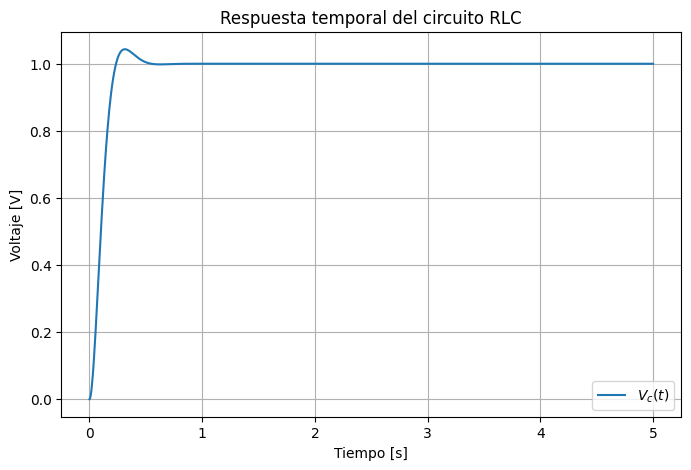

In [40]:
# -----------------------------
# Gráfica
# -----------------------------

plt.figure(figsize=(8, 5))
plt.plot(t, Vc, label=r"$V_c(t)$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.title("Respuesta temporal del circuito RLC")
plt.grid(True)
plt.legend()
plt.show()

## Respuesta del sistema para diferentes señales de entrada

### 1. Respuesta al impulso (función delta)

En la práctica, la función delta de Dirac $ \delta(t) $ se aproxima numéricamente mediante un pulso muy angosto y de área unitaria.
Esta entrada permite caracterizar completamente la dinámica del sistema.

La entrada se define como:

$ x(t) = \delta(t) $

In [41]:
def Vi(t):
    epsilon = 0.01
    return 1/epsilon if 0 <= t <= epsilon else 0

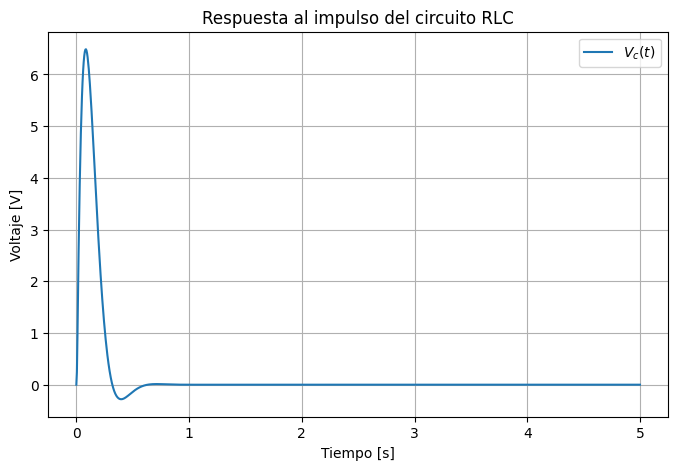

In [42]:
solution = solve_ivp(
    rlc_system,
    t_span,
    x0,
    t_eval=t_eval
)

t = solution.t
Vc = solution.y[0]

plt.figure(figsize=(8,5))
plt.plot(t, Vc, label=r"$V_c(t)$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.title("Respuesta al impulso del circuito RLC")
plt.grid(True)
plt.legend()
plt.show()

### 2. Respuesta al escalón

La función escalón unitario se define como:

$ x(t) = u(t) $

donde $u(t)=1$ para $t \geq 0$.

In [43]:
def Vi(t):
    return 1.0 if t >= 0 else 0.0

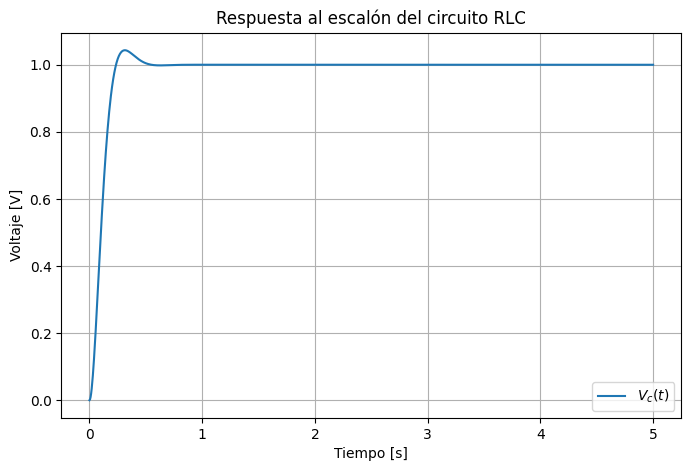

In [44]:
solution = solve_ivp(
    rlc_system,
    t_span,
    x0,
    t_eval=t_eval
)

t = solution.t
Vc = solution.y[0]

plt.figure(figsize=(8,5))
plt.plot(t, Vc, label=r"$V_c(t)$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.title("Respuesta al escalón del circuito RLC")
plt.grid(True)
plt.legend()
plt.show()

### 3. Respuesta a una señal sinusoidal

Se considera una entrada sinusoidal de amplitud unitaria y frecuencia angular $\omega$:

$ x(t) = \sin(\omega t) $

In [45]:
A = 1.0
omega = 2 * np.pi  # frecuencia angular (rad/s)

def Vi(t):
    return A * np.sin(omega * t)

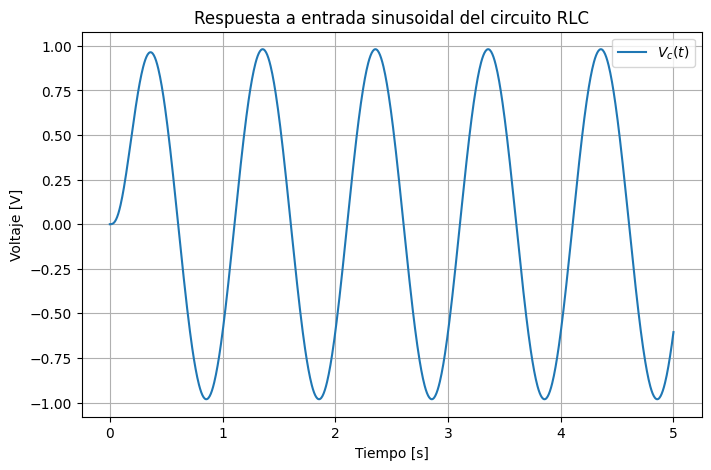

In [46]:
solution = solve_ivp(
    rlc_system,
    t_span,
    x0,
    t_eval=t_eval
)

t = solution.t
Vc = solution.y[0]

plt.figure(figsize=(8,5))
plt.plot(t, Vc, label=r"$V_c(t)$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.title("Respuesta a entrada sinusoidal del circuito RLC")
plt.grid(True)
plt.legend()
plt.show()

### 4. Respuesta a una señal cosenoidal

La señal cosenoidal se define como:

$ x(t) = \cos(\omega t) $

con la misma frecuencia angular $\omega$.

In [47]:
A = 1.0
omega = 2 * np.pi  # frecuencia angular (rad/s)

def Vi(t):
    return A * np.cos(omega * t)

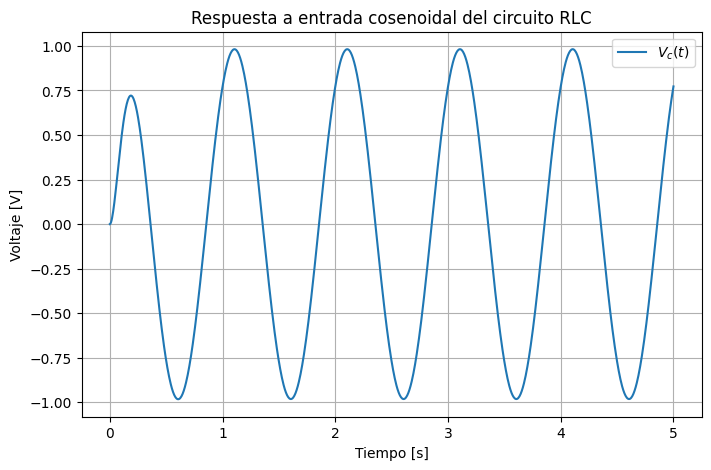

In [48]:
solution = solve_ivp(
    rlc_system,
    t_span,
    x0,
    t_eval=t_eval
)

t = solution.t
Vc = solution.y[0]

plt.figure(figsize=(8,5 ))
plt.plot(t, Vc, label=r"$V_c(t)$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.title("Respuesta a entrada cosenoidal del circuito RLC")
plt.grid(True)
plt.legend()
plt.show()